#### USE CODE FROM SKHASH FEEDER TO AUTOMATE THE PREPROCESSING

Assumption: If the arrival times work for a few test stations, they'll work for all

Input: rotated, filtered file of streams with acceptable snr

Outputs: manual polarity picks, amplitudes, noise and beachballs

In [1]:
import numpy as np
import pandas as pd
import os, sys, importlib
package_path = os.path.abspath('../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
from package import functions as fn
from obspy import read
from obspy import Stream
from collections import defaultdict
import copy
from matplotlib import pyplot as plt
from scipy.fft import fft, fftfreq
from obspy.clients.fdsn import Client
from obspy.taup import TauPyModel
import pickle
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
# load_pickle
with open("out/processed_data.pkl", "rb") as f:
    z_streams, l_streams_p, l_streams_s, az_epdist, \
        p_to_arvs_inc, s_to_arvs_inc, inventories = pickle.load(f)

for key in z_streams.keys():
    if len(z_streams[key]) > 3:
        loc = min({tr.stats.location for tr in z_streams[key]})
        z_streams[key] = z_streams[key].select(location=loc)
        l_streams_p[key] = l_streams_p[key].select(location=loc)
        l_streams_s[key] = l_streams_s[key].select(location=loc)

# read in catalog
catalog_df = pd.read_csv('out/catalog.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'processed_data.pkl'

In [ ]:
origin_time = catalog_df['time'].values[0]
origin_time = UTCDateTime(origin_time)
print(f"Origin time: {origin_time}")

Origin time: 2021-10-10T21:48:36.000000Z


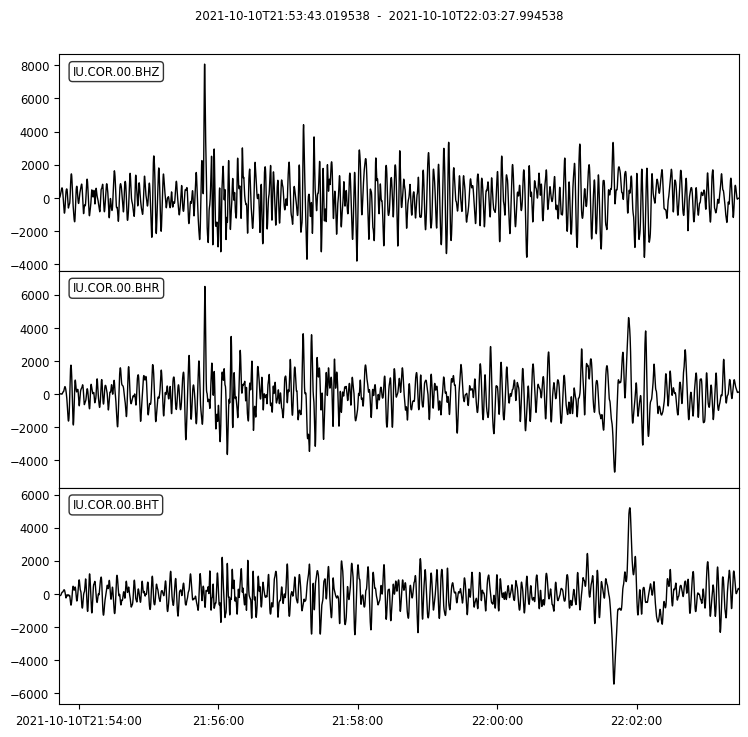

In [ ]:
index = -1
real_name = 'COR'
station_keys = list(z_streams.keys())
test_station = station_keys[index] if real_name is None else real_name
z_streams[test_station].plot();

In [ ]:
def plot_args(size):
    assert size in ['single', 'double', 'triple'], \
        "size must be either 'single' or 'double' or 'triple'"
    out = {
    'handle': True,
    'equal_scale': False,
    'transparent': True
    }
    if size == 'single':
        out['size'] = (800, 250)
    elif size == 'double':
        out['size'] = (800, 400)
    elif size == 'triple':
        out['size'] = (800, 600)
    return out

# P, Pn, Pg, pP, sP
phase_colors = {
    'p': 'red', 's': 'red',
    'P': 'blue', 'S': 'blue',
    'Pn': 'green', 'Sn': 'green',
    'Pg': 'orange', 'Sg': 'orange',
    'pP': 'black', 'pS': 'black',
    'sP': 'purple', 'sS': 'purple'
}

p_arrivals = p_to_arvs_inc[test_station][1]
p_times = [origin_time + arrival.time for arrival in p_arrivals]
p_phases = [arrival.name for arrival in p_arrivals]
p_colors = [phase_colors[arrival.name] for arrival in p_arrivals]
s_arrivals = s_to_arvs_inc[test_station][1]
s_times = [origin_time + arrival.time for arrival in s_arrivals]
s_phases = [arrival.name for arrival in s_arrivals]
s_colors = [phase_colors[arrival.name] for arrival in s_arrivals]

def vline_args(time, phase, color, legend, shift):
    out = {
        'x': mdates.date2num((time + shift).datetime),
        'color': color,
        'linestyle': '--',
        'linewidth': 0.5,
        'alpha': 1
    }
    if legend: out['label'] = phase
    return out

legend_args = {
    'loc': 'lower left',
    'fontsize': 8,
    'ncol': 2,
    'framealpha': 0.2
}

def trim_window(starttime, size):
    out = {
        'starttime': starttime,
        'endtime': starttime + size
    }
    return out

filter_args = {
    'type': 'lowpass',
    'freq': 0.2
}

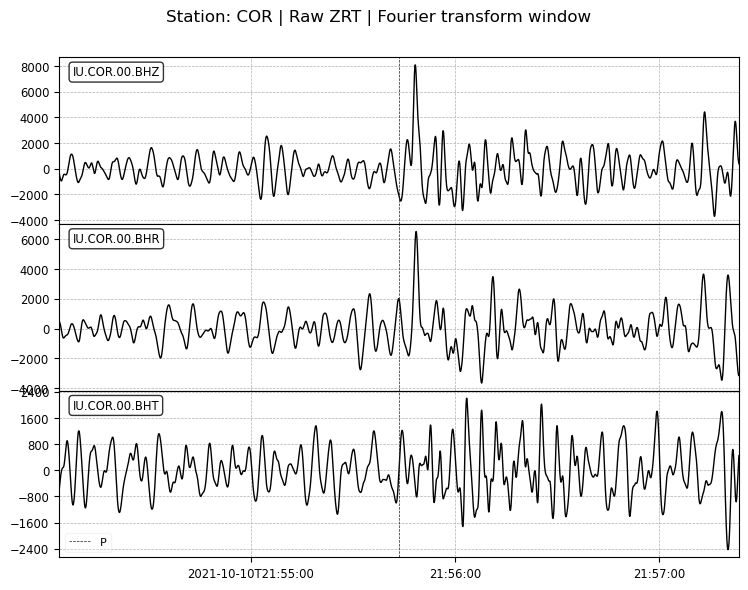

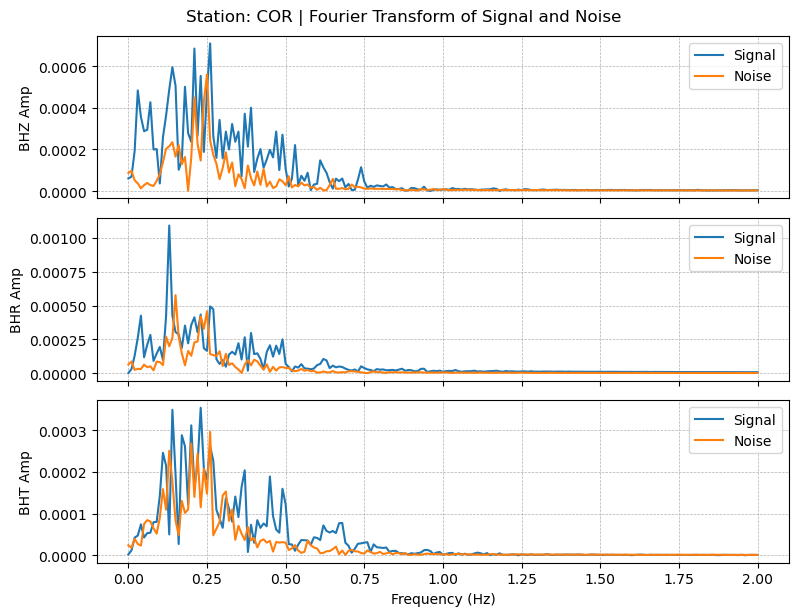

In [ ]:
# fourier plot to decide frequency thresholds
# use the zrt coordinates, make a plot for each channel deciding both the signal start/end, and the noise start/end
# start at earliest p arrival then go 30s forward for signal, then 30s before for noise
# plot combined zrt including signal and noise, mark off the split point btn signal and noise with axvline
# then trim that plot and fourier transform to make overlapping signal/noise spectra for each channel

fft_window_size = 100.0
freq_window = (0, 2) # Hz
stF = copy.deepcopy(z_streams[test_station])

# Raw ZRT (fourier)
p_starttime = min(p_times)
for tr in stF:
    tr.detrend(type='demean')
stF.trim(**trim_window(p_starttime - fft_window_size, 2*fft_window_size))
fig0 = stF.plot(**plot_args('triple'))
fig0.suptitle(f"Station: {test_station} | Raw ZRT | Fourier transform window")
for i in range(len(p_times[:1])):
    x_time, phase, color = p_times[i], p_phases[i], p_colors[i]
    for ax in fig0.axes:
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)  
        ax.axvline(**vline_args(x_time, phase, color, legend=True, shift=0))
    fig0.axes[-1].legend(**legend_args)

st_sig = copy.deepcopy(stF)
st_nse = copy.deepcopy(stF)
st_sig.trim(**trim_window(p_starttime, fft_window_size))
st_nse.trim(**trim_window(p_starttime-fft_window_size, fft_window_size))

# now do the fft plots
figF, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 6), sharex=True)
def mask_freqs(freqs, window):
    min_freq, max_freq = window
    mask = (freqs >= min_freq) & (freqs <= max_freq)
    return mask
for i in range(len(st_sig)):
    # signal
    sig_data = st_sig[i].data
    sig_n = len(sig_data)
    sig_dt = st_sig[i].stats.delta
    sig_freqs = fftfreq(sig_n, sig_dt)
    sig_fft = fft(sig_data)
    mask_sig = mask_freqs(sig_freqs, freq_window)
    axes[i].plot(sig_freqs[mask_sig], np.abs(sig_fft)[mask_sig], color='C0', label='Signal')
    
    # noise
    nse_data = st_nse[i].data
    nse_n = len(nse_data)
    nse_dt = st_nse[i].stats.delta
    nse_freqs = fftfreq(nse_n, nse_dt)
    nse_fft = fft(nse_data)
    mask_nse = mask_freqs(nse_freqs, freq_window)
    axes[i].plot(nse_freqs[mask_nse], np.abs(nse_fft)[mask_nse], color='C1', label='Noise')
    
    axes[i].set_ylabel(f"{st_sig[i].stats.channel} Amp")
    axes[i].legend()
    
    # grid with dashed lines
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.suptitle(f"Station: {test_station} | Fourier Transform of Signal and Noise", y=1.02)
plt.show()

NOTE: Pause here to adjust hyperparameters

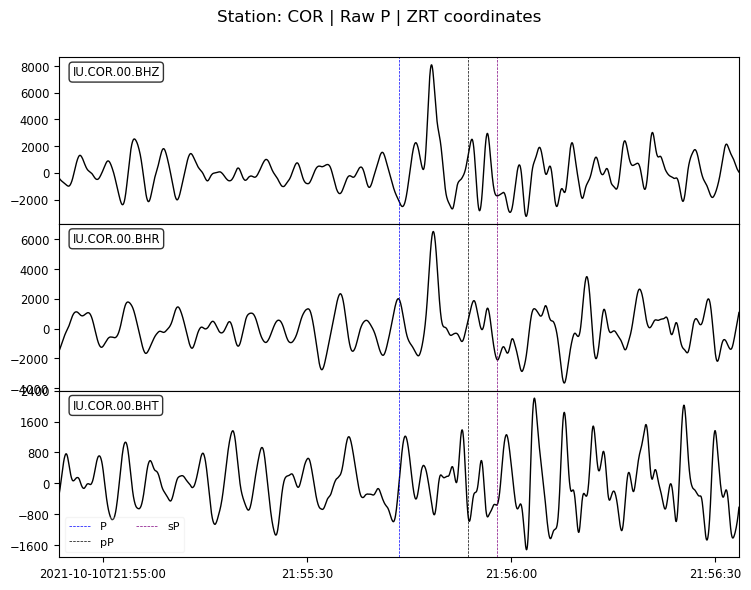

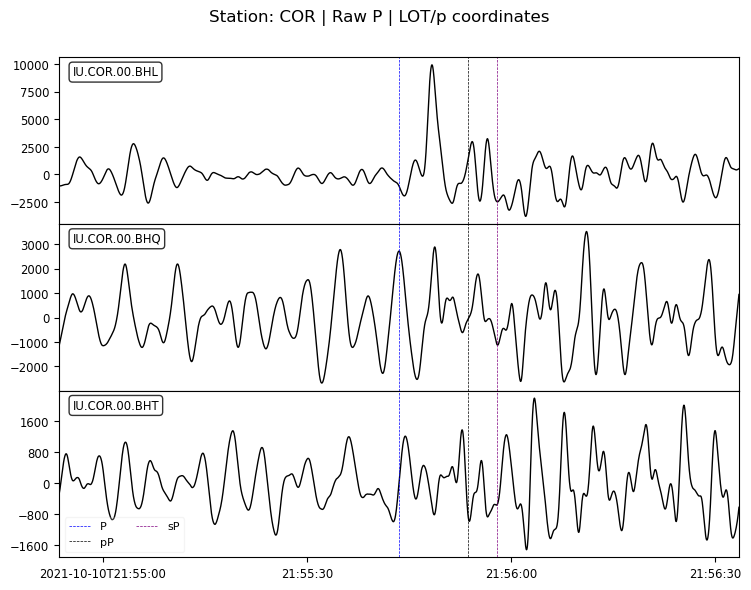

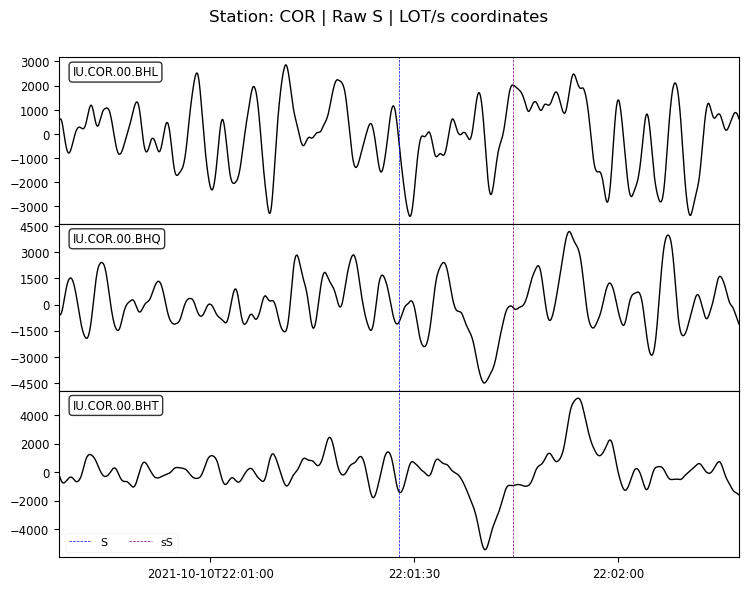

In [ ]:
pick_shift = 0.0
window_size = 100.0
starttime_buffer = 50.0

stZ = copy.deepcopy(z_streams[test_station])
stP = copy.deepcopy(l_streams_p[test_station])
stS = copy.deepcopy(l_streams_s[test_station])

# Raw ZRT
p_starttime = min(p_times) - starttime_buffer
for tr in stP:
    tr.detrend(type='demean')
stZ.trim(**trim_window(p_starttime, window_size))
fig1 = stZ.plot(**plot_args('triple'))
fig1.suptitle(f"Station: {test_station} | Raw P | ZRT coordinates")
fig1_done = set()
for i in range(len(p_times)):
    x_time, phase, color = p_times[i], p_phases[i], p_colors[i]
    legend = phase not in fig1_done
    plot_point = mdates.date2num((x_time + pick_shift).datetime)
    limits = fig1.axes[-1].get_xlim()
    if limits[0] <= plot_point <= limits[1]:
        for ax in fig1.axes:
            ax.axvline(**vline_args(x_time, phase, color, legend, pick_shift))
        fig1.axes[-1].legend(**legend_args)
    fig1_done.add(phase)

# Raw P
p_starttime = min(p_times) - starttime_buffer
for tr in stP:
    tr.detrend(type='demean')
stP.trim(**trim_window(p_starttime, window_size))
fig2 = stP.plot(**plot_args('triple'))
fig2.suptitle(f"Station: {test_station} | Raw P | LOT/p coordinates")
fig2_done = set()
for i in range(len(p_times)):
    x_time, phase, color = p_times[i], p_phases[i], p_colors[i]
    legend = phase not in fig2_done
    limits = fig2.axes[-1].get_xlim()
    plot_point = mdates.date2num((x_time + pick_shift).datetime)
    if limits[0] <= plot_point <= limits[1]:
        for ax in fig2.axes:
            ax.axvline(**vline_args(x_time, phase, color, legend, pick_shift))
        fig2.axes[-1].legend(**legend_args)
    fig2_done.add(phase)

# raw S
s_starttime = min(s_times) - starttime_buffer
for tr in stS:
    tr.detrend(type='demean')
stS.trim(**trim_window(s_starttime, window_size))
fig3 = stS.plot(**plot_args('triple'))
fig3.suptitle(f"Station: {test_station} | Raw S | LOT/s coordinates")
fig3_done = set()
for i in range(len(s_times)):
    x_time, phase, color = s_times[i], s_phases[i], s_colors[i]
    legend = phase not in fig3_done
    limits = fig3.axes[-1].get_xlim()
    plot_point = mdates.date2num((x_time + pick_shift).datetime)
    if limits[0] <= plot_point <= limits[1]:
        for ax in fig3.axes:
            ax.axvline(**vline_args(x_time, phase, color, legend, pick_shift))
        fig3.axes[-1].legend(**legend_args)
    fig3_done.add(phase)

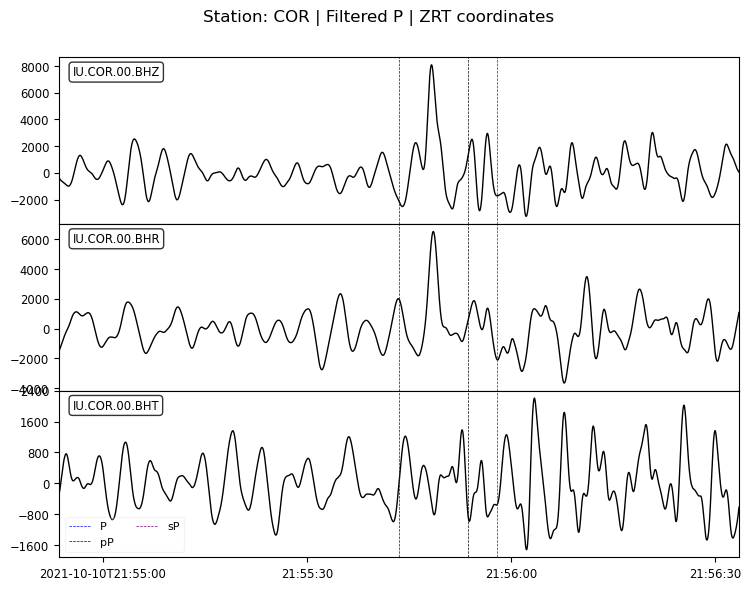

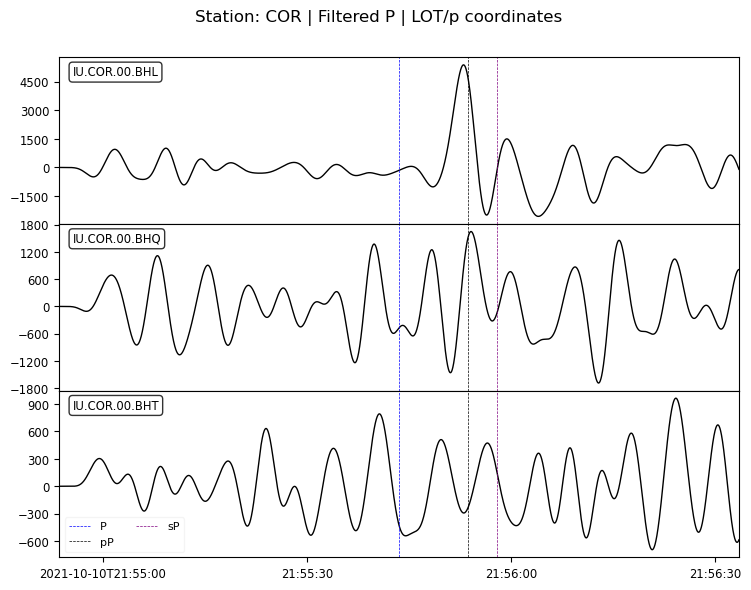

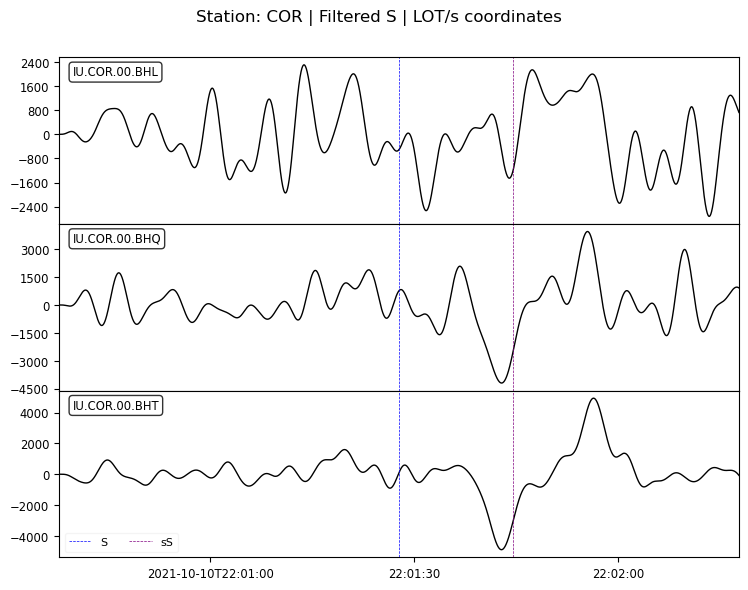

In [ ]:
# filtered ZRT
stP.filter(**filter_args)
fig4 = stZ.plot(**plot_args('triple'))
fig4.suptitle(f"Station: {test_station} | Filtered P | ZRT coordinates")
fig4_done = set()
for i in range(len(p_times)):
    x_time, phase, color = p_times[i], p_phases[i], p_colors[i]
    legend = phase not in fig4_done
    limits = fig4.axes[-1].get_xlim()
    plot_point = mdates.date2num((x_time + pick_shift).datetime)
    if limits[0] <= plot_point <= limits[1]:
        for ax in fig4.axes:
            ax.axvline(**vline_args(x_time, phase, color, legend, pick_shift))
        fig4.axes[-1].legend(**legend_args)
    fig4_done.add(phase)

# filtered P
stP.filter(**filter_args)
fig5 = stP.plot(**plot_args('triple'))
fig5.suptitle(f"Station: {test_station} | Filtered P | LOT/p coordinates")
fig5_done = set()
for i in range(len(p_times)):
    x_time, phase, color = p_times[i], p_phases[i], p_colors[i]
    legend = phase not in fig5_done
    limits = fig5.axes[-1].get_xlim()
    plot_point = mdates.date2num((x_time + pick_shift).datetime)
    if limits[0] <= plot_point <= limits[1]:
        for ax in fig5.axes:
            ax.axvline(**vline_args(x_time, phase, color, legend, pick_shift))
        fig5.axes[-1].legend(**legend_args)
    fig5_done.add(phase)
    
# filtered S
stS.filter(**filter_args)
fig6 = stS.plot(**plot_args('triple'))
fig6.suptitle(f"Station: {test_station} | Filtered S | LOT/s coordinates")
fig6_done = set()
for i in range(len(s_times)):
    x_time, phase, color = s_times[i], s_phases[i], s_colors[i]
    legend = phase not in fig6_done
    limits = fig6.axes[-1].get_xlim()
    plot_point = mdates.date2num((x_time + pick_shift).datetime)
    if limits[0] <= plot_point <= limits[1]:
        for ax in fig6.axes:
            ax.axvline(**vline_args(x_time, phase, color, legend, pick_shift))
        fig6.axes[-1].legend(**legend_args)
    fig6_done.add(phase)

#### INVERSION USING CUSTOM ALGORITHM

In [ ]:
# bring in pred_amps
pred_amps_df = pd.read_csv('out/pred_amps.csv')
# get the ones for anmo
p_pred = pred_amps_df[pred_amps_df['Station'] == test_station]['P_Amplitude'].values[0]
sv_pred = pred_amps_df[pred_amps_df['Station'] == test_station]['SV_Amplitude'].values[0]
sh_pred = pred_amps_df[pred_amps_df['Station'] == test_station]['SH_Amplitude'].values[0]
amp_pred = np.array([p_pred, sv_pred, sh_pred])
amp_pred

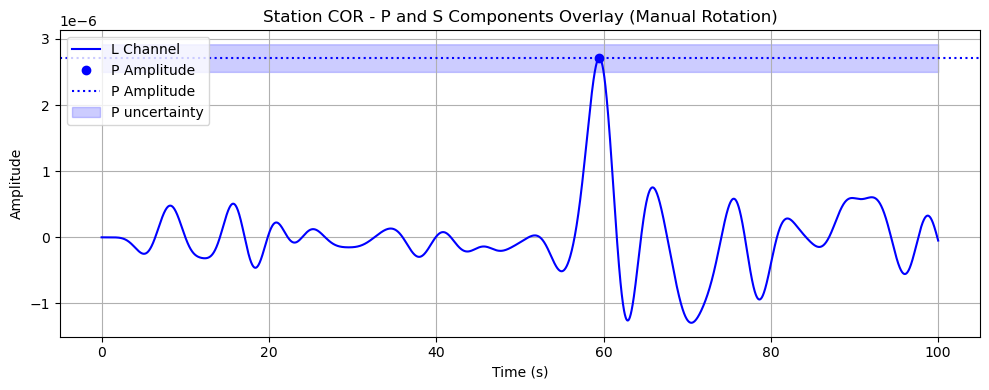

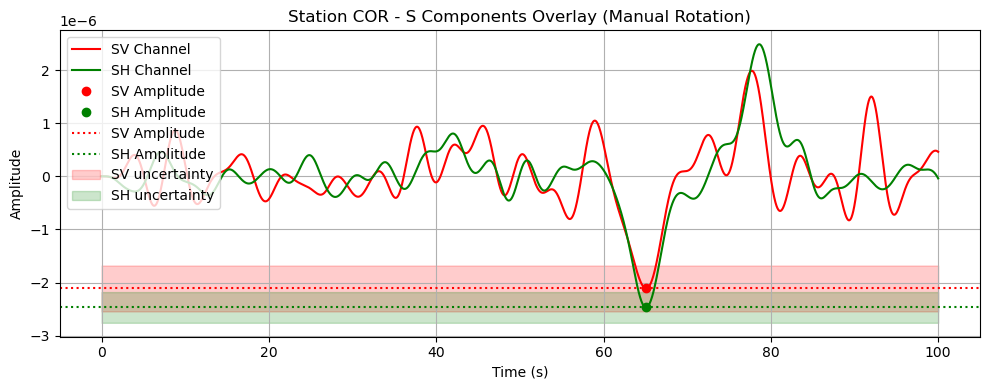

In [ ]:
# plotted amp picks
p_dim = (len(stP), len(stP[0].data))
data_p = np.zeros(p_dim)
for idx, tr in enumerate(stP): data_p[idx, :] = tr.data

# pick the amplitude position
p_delta = stP[0].stats.delta
p_shift = 7.0 # from visuals
p_xtime = min(p_times) + p_shift - stP[0].stats.starttime
p_pick_idx = int(p_xtime / p_delta)
p_half_window = int(2.0 / p_delta) # 2.0s window
p_amp = data_p[0, p_pick_idx-p_half_window:p_pick_idx+p_half_window].max()
p_amp_idx = data_p[0, p_pick_idx-p_half_window:p_pick_idx+p_half_window].argmax()\
    + (p_pick_idx-p_half_window)
p_unc_idx = p_amp_idx - int(2.0 / p_delta)
p_unc = np.std(data_p[0, :p_unc_idx])

s_dim = (len(stS), len(stS[1].data))
data_s = np.zeros(s_dim)
for idx, tr in enumerate(stS): data_s[idx, :] = tr.data

# pick the amplitude position
s_delta = stS[0].stats.delta
s_shift = 15.0
s_xtime = min(s_times) + s_shift - stS[0].stats.starttime
s_pick_idx = int(s_xtime / s_delta)
s_half_window = int(2.0 / s_delta) # 2.0s window
sv_amp = data_s[1, s_pick_idx-s_half_window:s_pick_idx+s_half_window].min()
sv_amp_idx = data_s[1, s_pick_idx-s_half_window:s_pick_idx+s_half_window].argmin()\
    + (s_pick_idx-s_half_window)
sh_amp = data_s[2, s_pick_idx-s_half_window:s_pick_idx+s_half_window].min()
sh_amp_idx = data_s[2, s_pick_idx-s_half_window:s_pick_idx+s_half_window].argmin() + (s_pick_idx-s_half_window)
s_unc_idx = min(sv_amp_idx, sh_amp_idx) - int(2.0 / s_delta)
sv_unc = np.std(data_s[1, :s_unc_idx])
sh_unc = np.std(data_s[2, :s_unc_idx])


amp_obs = np.array([p_amp, sv_amp, sh_amp])
proj_pred = (amp_obs @ amp_pred) / (amp_pred @ amp_pred) * amp_pred
p_proj, sv_proj, sh_proj = proj_pred

# overlayed plot of channels at p-arrival
figP, axP = plt.subplots(figsize=(10, 4))
times_p = np.arange(data_p.shape[1]) * p_delta # + (p_start - p_init)
axP.plot(times_p, data_p[0, :], 'b', label='L Channel')
axP.plot(times_p[p_amp_idx], p_amp, 'bo', label='P Amplitude')
axP.axhline(y=p_amp, color='b', linestyle=':', label='P Amplitude')
axP.axhline(y=p_proj, color='b', linestyle='--', label='P Projected Amplitude')
plt.fill_between(times_p, p_amp-p_unc, p_amp+p_unc, color='b', alpha=0.2, label='P uncertainty')
axP.set_xlabel('Time (s)')
axP.set_ylabel('Amplitude')
axP.set_title(f'Station {test_station} - P and S Components Overlay (Manual Rotation)')
axP.legend(loc='upper left')
axP.grid()
plt.tight_layout()
plt.show()



# overlayed plot of channels at s-arrival
figS, axS = plt.subplots(figsize=(10, 4))
times_s = np.arange(data_s.shape[1]) * s_delta # + (s_start - s_init)
axS.plot(times_s, data_s[1, :], 'r', label='SV Channel')
axS.plot(times_s, data_s[2, :], 'g', label='SH Channel')
axS.plot(times_s[sv_amp_idx], sv_amp, 'ro', label='SV Amplitude')
axS.plot(times_s[sh_amp_idx], sh_amp, 'go', label='SH Amplitude')
axS.axhline(y=sv_amp, color='r', linestyle=':', label='SV Amplitude')
axS.axhline(y=sh_amp, color='g', linestyle=':', label='SH Amplitude')
axS.axhline(y=sv_proj, color='r', linestyle='--', label='SV Projected Amplitude')
axS.axhline(y=sh_proj, color='g', linestyle='--', label='SH Projected Amplitude')
plt.fill_between(times_s, sv_amp-sv_unc, sv_amp+sv_unc, color='r', alpha=0.2, label='SV uncertainty')
plt.fill_between(times_s, sh_amp-sh_unc, sh_amp+sh_unc, color='g', alpha=0.2, label='SH uncertainty')
axS.set_xlabel('Time (s)')
axS.set_ylabel('Amplitude')
axS.set_title(f'Station {test_station} - S Components Overlay (Manual Rotation)')
axS.legend(loc='upper left')
axS.grid()
plt.tight_layout()
plt.show()

In [20]:
np.random.seed(13)

az_rad = np.deg2rad(az_epdist[test_station][0])
p_to_rad = np.pi - np.deg2rad(p_to_arvs_inc[test_station][0])
s_to_rad = np.pi - np.deg2rad(s_to_arvs_inc[test_station][0])
tos_rad = [p_to_rad, s_to_rad]
hdepth = catalog_df['depth'].values[0]
vel_model_path = '../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)
velocities = fn.extract_velocities(lookup_table, hdepth)
observed_Ao = np.array([p_amp, sv_amp, sh_amp])
observed_unc = np.array([p_unc, sv_unc, sh_unc])

radiation_model = rm.RadiationModel(az_rad, tos_rad, velocities)
radiation_model.set_Ao(observed_Ao)
radiation_model.set_Uo(observed_unc)
benchmark = np.array([190, 30, 9])
radiation_model.set_real_sdr(np.deg2rad(benchmark))

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 4000

# multistart optimization
num_starts =50
starts = fn.random_params(num_starts)

radiation_model.reset()
print_every = 10

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(radiation_model, config, start)

print(f'Convergence rate: {radiation_model.get_convergence_rate():.0f}%')

Using sdr parameters.
Run 0 of 50


Run 10 of 50
Run 20 of 50
Run 30 of 50
Run 40 of 50
Convergence rate: 94%


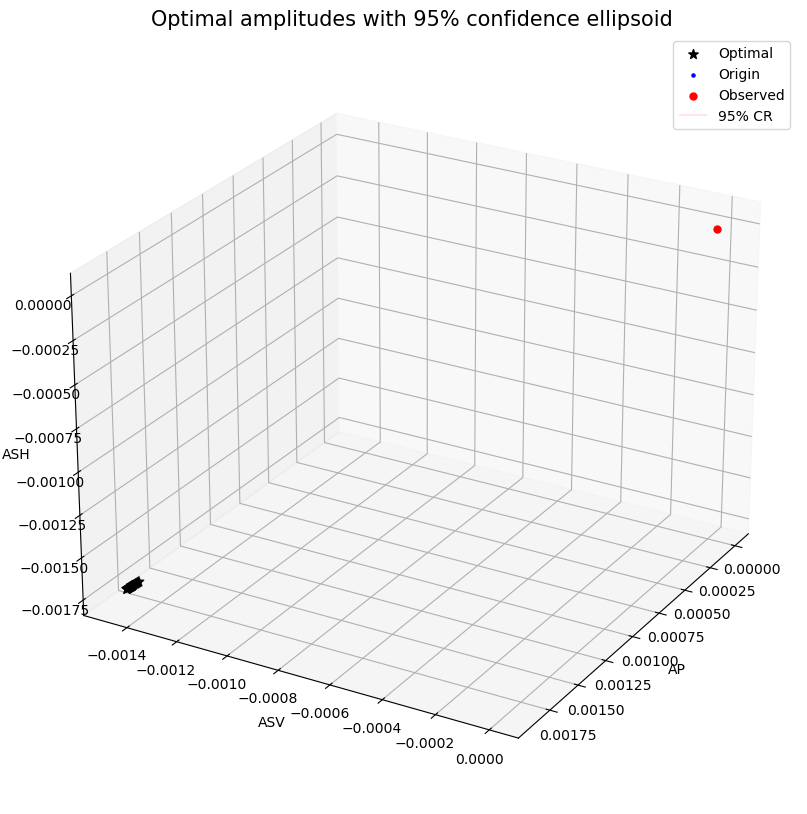

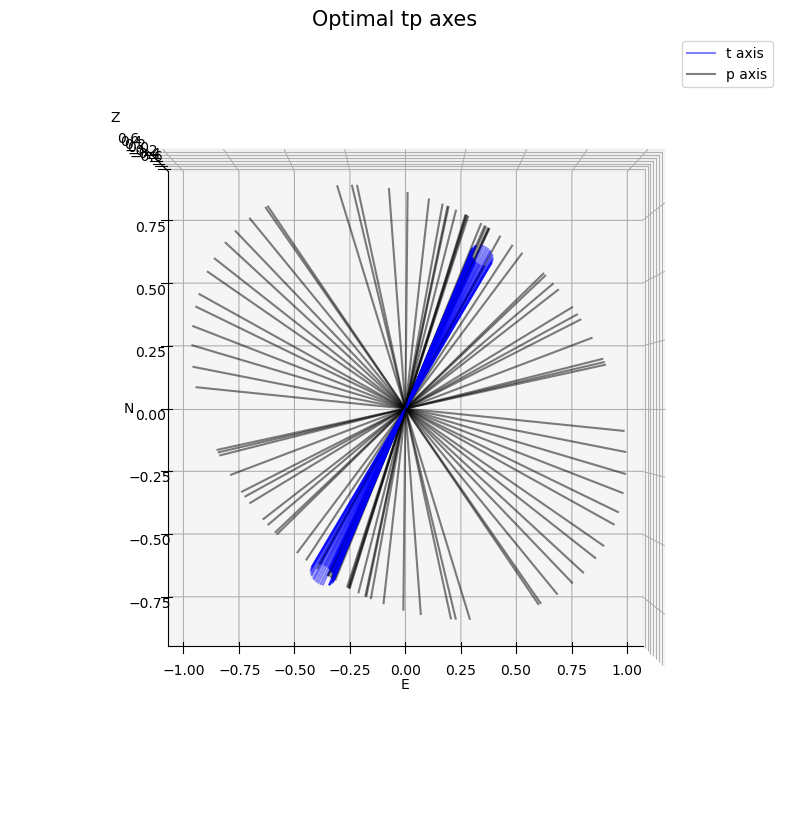

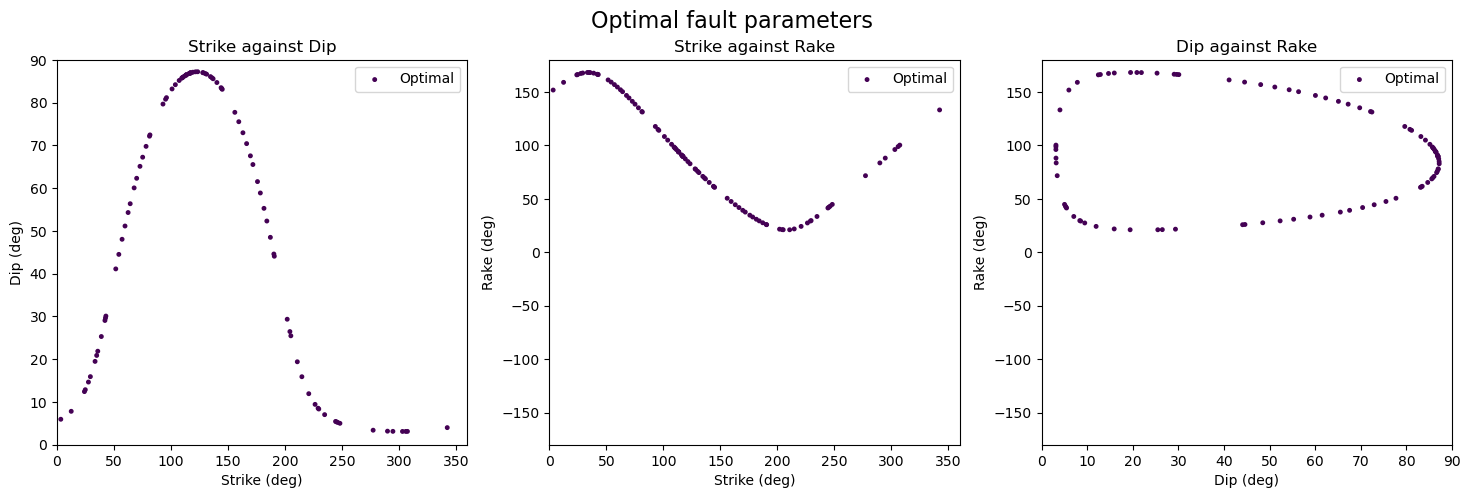

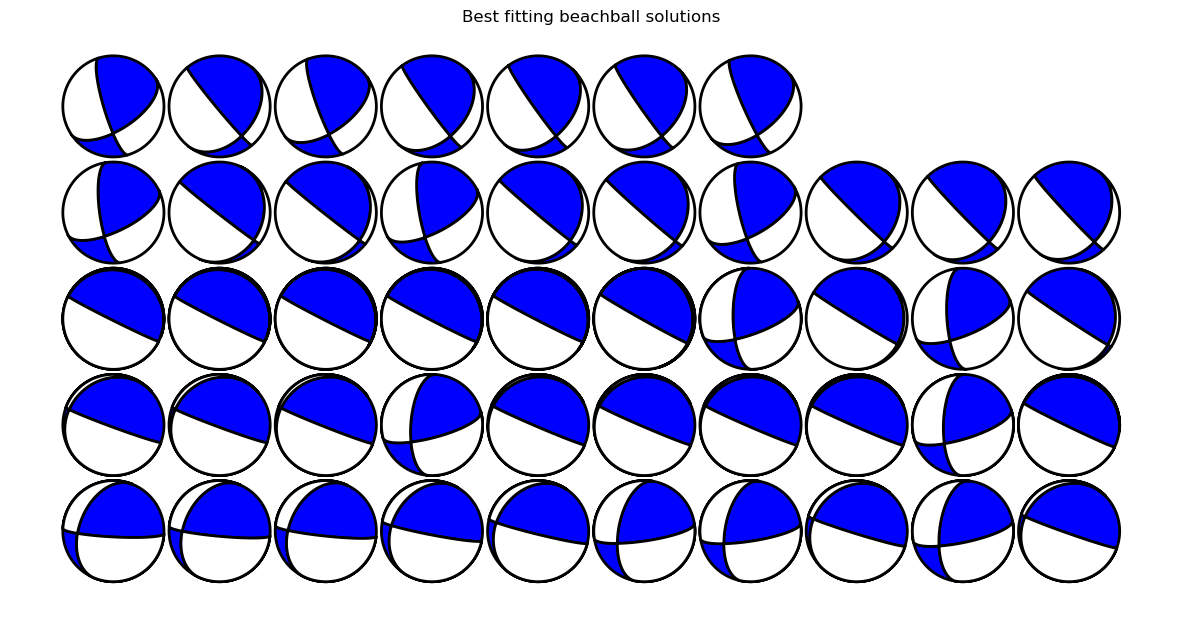

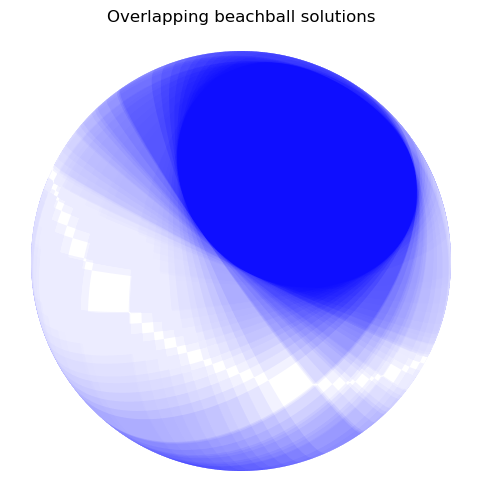

In [22]:
importlib.reload(plots)
# amplitude plot
radiation_model.reset_grid_amplitudes()
radiation_model.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(radiation_model, azim=30, elev=25, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(radiation_model, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(radiation_model, s=25, optimal=True, index=2, cmap='viridis')

# beachball plots
plots.beachballs(radiation_model, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=False)

# overlapping beachball plot
plots.beachballs(radiation_model, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=False)